# Homework 1 - Pattern Recognition and Machine Learning

**Bayesian classification, Gaussian discriminant models, LDA i QDA**

Consider two classes $\omega_1, \omega_2 \in \mathbb{R}^2$:

$$\omega_1 \sim \mathcal{N}(\mu_1, \Sigma_1), \qquad \omega_2 \sim \mathcal{N}(\mu_2, \Sigma_2)$$

with
$$
\mu_1 = \begin{bmatrix}0\\0\end{bmatrix}, \quad
\mu_2 = \begin{bmatrix}2\\2\end{bmatrix},\qquad
\Sigma_1 = \begin{bmatrix}1.0 & 0.6\\0.6 & 1.2\end{bmatrix}, \quad
\Sigma_2 = \begin{bmatrix}1.2 & -0.4\\-0.4 & 1.0\end{bmatrix}
$$
and equal priors $P(\omega_1) = P(\omega_2) = 0.5$.

Bayes rule and discriminant function:
$$
P(\omega_i \mid x) = \frac{p(x \mid \omega_i) P(\omega_i)}{p(x)}, \qquad
g_i(x) = \ln p(x \mid \omega_i) + \ln P(\omega_i).
$$

The class with the largest $g_i(x)$ is chosen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

mu1 = np.array([0.0, 0.0])
mu2 = np.array([2.0, 2.0])

Sigma1 = np.array([[1.0, 0.6],
                   [0.6, 1.2]])
Sigma2 = np.array([[1.2, -0.4],
                   [-0.4, 1.0]])

P1 = 0.5
P2 = 0.5

### Multivariate Gaussian PDF i log-discriminant

$$
p(x \mid \mu, \Sigma) = \frac{1}{(2\pi)^{d/2}\,|\Sigma|^{1/2}}
\exp\!\left(-\tfrac{1}{2}(x-\mu)^{\top}\Sigma^{-1}(x-\mu)\right)
$$

**Log-space** because of numerical stability:
$$
\ln p(x \mid \mu, \Sigma) = -\tfrac{d}{2}\ln(2\pi) - \tfrac{1}{2}\ln|\Sigma| - \tfrac{1}{2}(x-\mu)^{\top}\Sigma^{-1}(x-\mu).
$$


In [2]:
def gaussian_pdf(x, mu, Sigma):
    """MGPDF, x point (d,) or batch (n, d)"""
    x = np.atleast_2d(x)
    d = mu.shape[0]
    diff = x - mu
    inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)
    coeff = 1.0 / np.sqrt((2 * np.pi) ** d * det)
    exponent = -0.5 * np.einsum('ni,ij,nj->n', diff, inv, diff)
    return coeff * np.exp(exponent)


def log_gaussian_pdf(x, mu, Sigma):
    x = np.atleast_2d(x)
    d = mu.shape[0]
    diff = x - mu
    inv = np.linalg.inv(Sigma)
    sign, logdet = np.linalg.slogdet(Sigma)
    quad = np.einsum('ni,ij,nj->n', diff, inv, diff)
    return -0.5 * (d * np.log(2 * np.pi) + logdet + quad)


def log_discriminant(x, mu, Sigma, prior):
    return log_gaussian_pdf(x, mu, Sigma) + np.log(prior)

# 1 / Bayes classifier

## a) 400 samples from each class

In [3]:
n = 400

X1 = np.random.multivariate_normal(mu1, Sigma1, size=n)
X2 = np.random.multivariate_normal(mu2, Sigma2, size=n)

X = np.vstack([X1, X2])
y = np.array([1] * n + [2] * n) 

print("X shape:", X.shape)
print("Class 1 sample mean:", X1.mean(axis=0))
print("Class 2 sample mean:", X2.mean(axis=0))

X shape: (800, 2)
Class 1 sample mean: [0.10648452 0.06351173]
Class 2 sample mean: [1.97199781 2.06048136]


## b) Visualizing generated samples

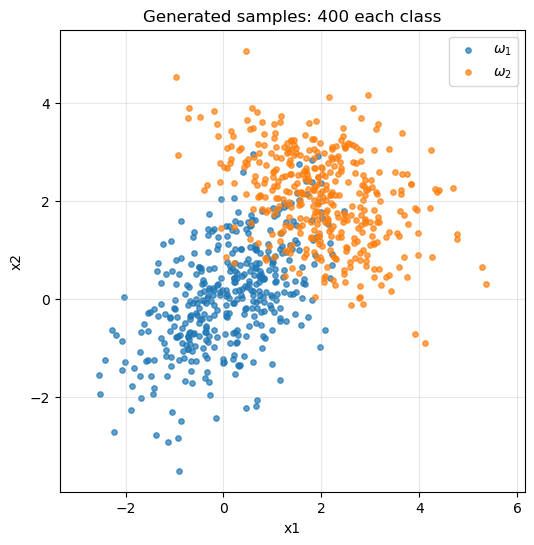

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(X1[:, 0], X1[:, 1], s=15, alpha=0.7, label=r"$\omega_1$")
plt.scatter(X2[:, 0], X2[:, 1], s=15, alpha=0.7, label=r"$\omega_2$")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Generated samples: 400 each class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

## c) Bayes classifier with true parameters

We implement the classifier via the log-discriminant function:
$$
\hat{y}(x) = \arg\max_{i \in {1,2}} \big[\ln p(x \mid \omega_i) + \ln P(\omega_i)\big].
$$

Since the priors are equal, the decision boundary is where $p(x \mid \omega_1) = p(x \mid \omega_2)$.

In [5]:
def bayes_classifier(X, mu1, Sigma1, P1, mu2, Sigma2, P2):
    """Labels {1, 2} for each batch X (n, d)."""
    g1 = log_discriminant(X, mu1, Sigma1, P1)
    g2 = log_discriminant(X, mu2, Sigma2, P2)
    return np.where(g1 > g2, 1, 2)


def posterior_probs(X, mu1, Sigma1, P1, mu2, Sigma2, P2):
    """Vrati P(omega_1 | x), P(omega_2 | x) — vektorizovano."""
    p1 = gaussian_pdf(X, mu1, Sigma1) * P1
    p2 = gaussian_pdf(X, mu2, Sigma2) * P2
    denom = np.maximum(p1 + p2, 1e-300)
    return p1 / denom, p2 / denom

## d) Classifying generated samples

In [6]:
y_pred_bayes = bayes_classifier(X, mu1, Sigma1, P1, mu2, Sigma2, P2)
print("First 10 predictions:", y_pred_bayes[:10])
print("Class distribution:", np.bincount(y_pred_bayes)[1:])

First 10 predictions: [1 1 1 1 1 1 1 1 1 1]
Class distribution: [376 424]


## e) Confusion matrix, accurancy and empirical error

Confusion matrix: $C_{ij}$ = number of samples from true class $\omega_i$ predicted as $\omega_j$.
$$\text{accuracy} = \frac{TP + TN}{N}, \qquad \text{empirical error rate} = 1 - \text{accuracy}.$$


In [7]:
def confusion_matrix_2x2(y_true, y_pred):
    cm = np.zeros((2, 2), dtype=int)
    for true_label in (1, 2):
        for pred_label in (1, 2):
            cm[true_label - 1, pred_label - 1] = np.sum(
                (y_true == true_label) & (y_pred == pred_label))
    return cm


def report_metrics(y_true, y_pred, name=""):
    cm = confusion_matrix_2x2(y_true, y_pred)
    acc = np.mean(y_true == y_pred)
    err = 1 - acc
    print(f"--- {name} ---")
    print("Confusion matrix (rows = T, cols = P):")
    print(f"          pred=1   pred=2")
    print(f"true=1   {cm[0,0]:>6}   {cm[0,1]:>6}")
    print(f"true=2   {cm[1,0]:>6}   {cm[1,1]:>6}")
    print(f"Accuracy:              {acc:.4f}")
    print(f"Empirical error rate:  {err:.4f}")
    return cm, acc, err


cm_bayes, acc_bayes, err_bayes = report_metrics(y, y_pred_bayes, "Bayes (true params, equal priors)")

--- Bayes (true params, equal priors) ---
Confusion matrix (rows = T, cols = P):
          pred=1   pred=2
true=1      357       43
true=2       19      381
Accuracy:              0.9225
Empirical error rate:  0.0775


## f) Visualization of the Bayes classifier decision regions

We create a dense grid and compute the classifier prediction for each point, as well as the true decision boundary $g_1(x) - g_2(x) = 0$ as a contour line.

In [8]:
def make_grid(X, pad=1.0, n=300):
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n),
                         np.linspace(y_min, y_max, n))
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def plot_decision_regions(X1, X2, predict_fn, score_fn=None, title=""):
    X_all = np.vstack([X1, X2])
    xx, yy, grid = make_grid(X_all)
    Z = predict_fn(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, alpha=0.25, levels=[0.5, 1.5, 2.5])
    if score_fn is not None:
        S = score_fn(grid).reshape(xx.shape)
        plt.contour(xx, yy, S, levels=[0.0], colors='black', linewidths=1.5)
    plt.scatter(X1[:, 0], X1[:, 1], s=12, alpha=0.7, label=r"$\omega_1$")
    plt.scatter(X2[:, 0], X2[:, 1], s=12, alpha=0.7, label=r"$\omega_2$")
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

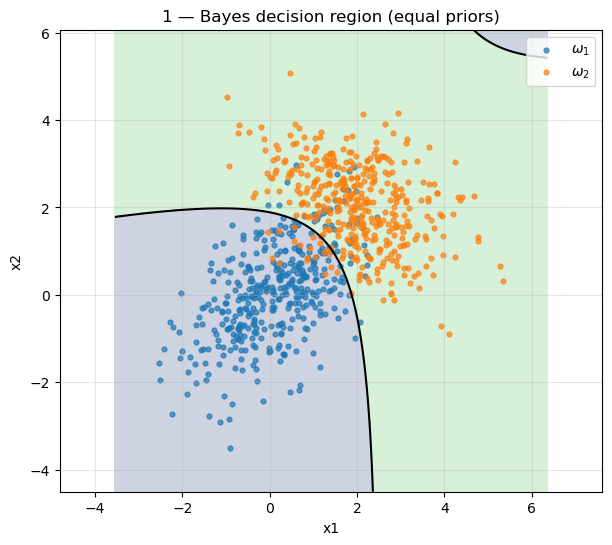

In [9]:
predict_bayes = lambda Xg: bayes_classifier(Xg, mu1, Sigma1, P1, mu2, Sigma2, P2)
score_bayes  = lambda Xg: (log_discriminant(Xg, mu1, Sigma1, P1)
                           - log_discriminant(Xg, mu2, Sigma2, P2))

plot_decision_regions(X1, X2, predict_bayes, score_bayes,
                      title="1 — Bayes decision region (equal priors)")

# 2 / Effect of prior probabilities

The likelihoods $p(x \mid \omega_i)$ remain the same — only the priors change.
The discriminant shifts through $\ln P(\omega_i)$, which directly moves the decision boundary.

- **Case A:** $P(\omega_1) = 0.8,\ P(\omega_2) = 0.2$
- **Case B:** $P(\omega_1) = 0.2,\ P(\omega_2) = 0.8$


In [10]:
# Case A
P1_A, P2_A = 0.8, 0.2
y_pred_A = bayes_classifier(X, mu1, Sigma1, P1_A, mu2, Sigma2, P2_A)
cm_A, acc_A, err_A = report_metrics(y, y_pred_A, "Case A: P1=0.8, P2=0.2")

--- Case A: P1=0.8, P2=0.2 ---
Confusion matrix (rows = T, cols = P):
          pred=1   pred=2
true=1      379       21
true=2       66      334
Accuracy:              0.8912
Empirical error rate:  0.1088


In [11]:
# Case B
P1_B, P2_B = 0.2, 0.8
y_pred_B = bayes_classifier(X, mu1, Sigma1, P1_B, mu2, Sigma2, P2_B)
cm_B, acc_B, err_B = report_metrics(y, y_pred_B, "Case B: P1=0.2, P2=0.8")

--- Case B: P1=0.2, P2=0.8 ---
Confusion matrix (rows = T, cols = P):
          pred=1   pred=2
true=1      317       83
true=2        5      395
Accuracy:              0.8900
Empirical error rate:  0.1100


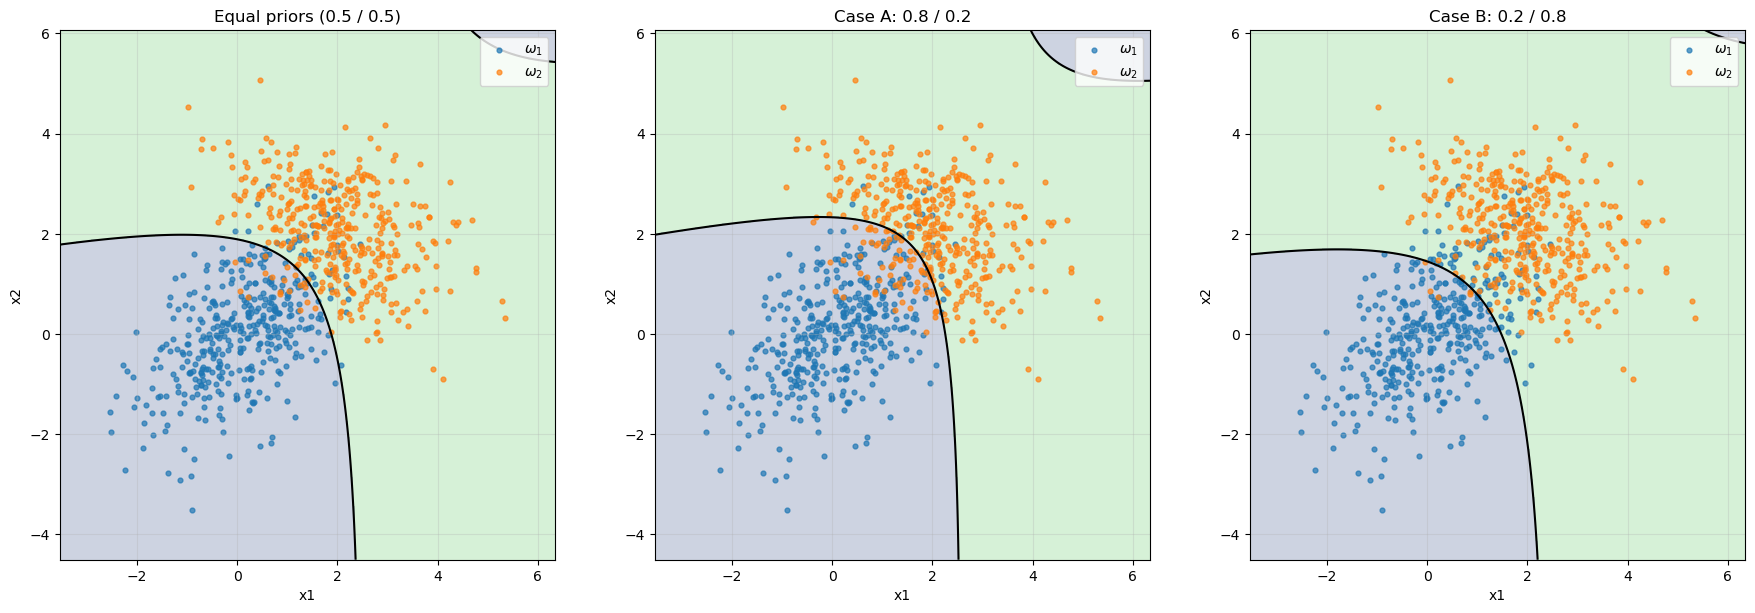

In [12]:
def make_pred_score(P1_, P2_):
    pred = lambda Xg: bayes_classifier(Xg, mu1, Sigma1, P1_, mu2, Sigma2, P2_)
    score = lambda Xg: (log_discriminant(Xg, mu1, Sigma1, P1_)
                        - log_discriminant(Xg, mu2, Sigma2, P2_))
    return pred, score

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (P1_, P2_, ttl) in zip(axes, [
        (0.5, 0.5, "Equal priors (0.5 / 0.5)"),
        (0.8, 0.2, "Case A: 0.8 / 0.2"),
        (0.2, 0.8, "Case B: 0.2 / 0.8")]):
    pred, score = make_pred_score(P1_, P2_)
    xx, yy, grid = make_grid(X)
    Z = pred(grid).reshape(xx.shape)
    S = score(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, levels=[0.5, 1.5, 2.5])
    ax.contour(xx, yy, S, levels=[0.0], colors='black', linewidths=1.5)
    ax.scatter(X1[:, 0], X1[:, 1], s=12, alpha=0.7, label=r"$\omega_1$")
    ax.scatter(X2[:, 0], X2[:, 1], s=12, alpha=0.7, label=r"$\omega_2$")
    ax.set_title(ttl); ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

In [13]:
print("Summary:")
print(f"  Equal priors (0.5/0.5):  acc = {acc_bayes:.4f},  err = {err_bayes:.4f}")
print(f"  Case A (0.8/0.2):        acc = {acc_A:.4f},  err = {err_A:.4f}")
print(f"  Case B (0.2/0.8):        acc = {acc_B:.4f},  err = {err_B:.4f}")

Summary:
  Equal priors (0.5/0.5):  acc = 0.9225,  err = 0.0775
  Case A (0.8/0.2):        acc = 0.8912,  err = 0.1088
  Case B (0.2/0.8):        acc = 0.8900,  err = 0.1100


### Discussion

- **How does the decision boundary move when priors change??**
    The boundary shifts away from the class with the higher prior and toward the class with the lower prior. The region of the class with the larger prior expands, increasing the probability that an unseen point is assigned to that class.

- **Which class is easier to predict now??**
    The class with the higher prior. Case A favors $\omega_1$, while Case B favors $\omega_2$. This is also reflected in the confusion matrices: errors for the higher-prior class decrease, while errors for the lower-prior class increase.

- **Why does changing priors affect the rule even though likelihoods stay the same??**
    In the log-discriminant $g_i(x) = \ln p(x \mid \omega_i) + \ln P(\omega_i)$, the term $\ln P(\omega_i)$ depends only on the prior. The difference $g_1(x) - g_2(x)$ shifts by $\ln(P_1/P_2)$, which moves the zero level set (the decision boundary). The Bayes-optimal rule does not only depend on $p(x \mid \omega)$, but on the joint probability $p(x, \omega) = p(x \mid \omega) P(\omega)$, so changing priors directly changes the optimal decision.


# 3 / Bayes vs LDA vs QDA

## a) Train/test split 70/30

We split the dataset in a stratified manner by class.

In [14]:
def stratified_split(X, y, test_size=0.3, seed=1):
    rng = np.random.default_rng(seed)
    idx_train, idx_test = [], []
    for c in np.unique(y):
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)
        n_test = int(round(len(idx_c) * test_size))
        idx_test.append(idx_c[:n_test])
        idx_train.append(idx_c[n_test:])
    idx_train = np.concatenate(idx_train); rng.shuffle(idx_train)
    idx_test  = np.concatenate(idx_test);  rng.shuffle(idx_test)
    return X[idx_train], X[idx_test], y[idx_train], y[idx_test]


X_train, X_test, y_train, y_test = stratified_split(X, y, test_size=0.3, seed=1)
print("Train:", X_train.shape, "  Test:", X_test.shape)
print("Class counts (train):", np.bincount(y_train)[1:])
print("Class counts (test):",  np.bincount(y_test)[1:])

Train: (560, 2)   Test: (240, 2)
Class counts (train): [280 280]
Class counts (test): [120 120]


## b) Training LDA and QDA

**QDA** — each class has its own covariance:
$$\hat\mu_k = \tfrac{1}{n_k}\sum_{i:y_i=k} x_i, \qquad
\hat\Sigma_k = \tfrac{1}{n_k}\sum_{i:y_i=k}(x_i - \hat\mu_k)(x_i - \hat\mu_k)^\top.$$

**LDA** — *shared* (pooled) covariance:
$$\hat\Sigma = \tfrac{1}{n}\sum_{k}\sum_{i:y_i=k} (x_i - \hat\mu_k)(x_i - \hat\mu_k)^\top.$$

With a shared covariance, the quadratic term cancels out, resulting in a **linear** decision boundary.

In [15]:
def fit_qda(X, y):
    classes = np.unique(y)
    means, covs, priors = {}, {}, {}
    for c in classes:
        Xc = X[y == c]
        means[c] = Xc.mean(axis=0)
        diff = Xc - means[c]
        covs[c] = (diff.T @ diff) / Xc.shape[0]
        priors[c] = Xc.shape[0] / X.shape[0]
    return means, covs, priors


def fit_lda(X, y):
    classes = np.unique(y)
    means, priors = {}, {}
    pooled = np.zeros((X.shape[1], X.shape[1]))
    for c in classes:
        Xc = X[y == c]
        means[c] = Xc.mean(axis=0)
        diff = Xc - means[c]
        pooled += diff.T @ diff
        priors[c] = Xc.shape[0] / X.shape[0]
    pooled /= X.shape[0]
    return means, pooled, priors


def predict_qda(X, means, covs, priors):
    classes = sorted(means.keys())
    scores = np.column_stack([
        log_gaussian_pdf(X, means[c], covs[c]) + np.log(priors[c])
        for c in classes
    ])
    return np.array(classes)[np.argmax(scores, axis=1)]


def predict_lda(X, means, pooled, priors):
    classes = sorted(means.keys())
    scores = np.column_stack([
        log_gaussian_pdf(X, means[c], pooled) + np.log(priors[c])
        for c in classes
    ])
    return np.array(classes)[np.argmax(scores, axis=1)]

In [17]:
qda_means, qda_covs, qda_priors = fit_qda(X_train, y_train)

lda_means, lda_pooled, lda_priors = fit_lda(X_train, y_train)

print("QDA estimated mu1:", qda_means[1])
print("QDA estimated mu2:", qda_means[2])
print("QDA estimated Sigma1:\n", qda_covs[1])
print("QDA estimated Sigma2:\n", qda_covs[2])
print("LDA pooled Sigma:\n", lda_pooled)

QDA estimated mu1: [0.03761782 0.03982793]
QDA estimated mu2: [1.98124681 2.03166912]
QDA estimated Sigma1:
 [[0.91884185 0.58798419]
 [0.58798419 1.23832401]]
QDA estimated Sigma2:
 [[ 1.24160657 -0.41605939]
 [-0.41605939  0.93174943]]
LDA pooled Sigma:
 [[1.08022421 0.0859624 ]
 [0.0859624  1.08503672]]


## c) Evaluation on the test set

In [18]:
y_pred_bayes_test = bayes_classifier(X_test, mu1, Sigma1, P1, mu2, Sigma2, P2)
y_pred_lda_test   = predict_lda(X_test, lda_means, lda_pooled, lda_priors)
y_pred_qda_test   = predict_qda(X_test, qda_means, qda_covs, qda_priors)

print("=== Test-set performance ===\n")
report_metrics(y_test, y_pred_bayes_test, "Bayes (true params)")
print()
report_metrics(y_test, y_pred_lda_test, "LDA")
print()
report_metrics(y_test, y_pred_qda_test, "QDA")

=== Test-set performance ===

--- Bayes (true params) ---
Confusion matrix (rows = T, cols = P):
          pred=1   pred=2
true=1      104       16
true=2        4      116
Accuracy:              0.9167
Empirical error rate:  0.0833

--- LDA ---
Confusion matrix (rows = T, cols = P):
          pred=1   pred=2
true=1       99       21
true=2        2      118
Accuracy:              0.9042
Empirical error rate:  0.0958

--- QDA ---
Confusion matrix (rows = T, cols = P):
          pred=1   pred=2
true=1      104       16
true=2        5      115
Accuracy:              0.9125
Empirical error rate:  0.0875


(array([[104,  16],
        [  5, 115]]),
 np.float64(0.9125),
 np.float64(0.08750000000000002))

### Visualization of decision regions (Bayes / LDA / QDA)

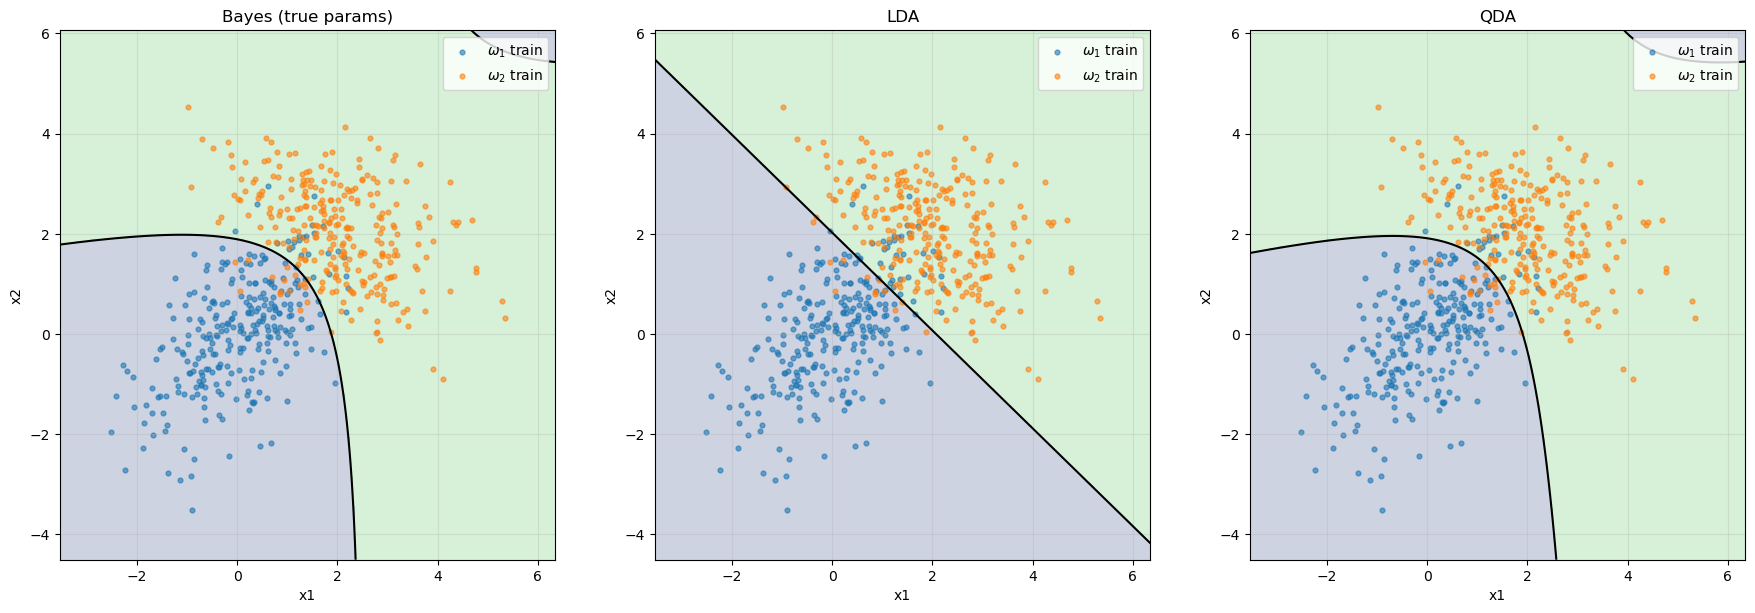

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

specs = [
    ("Bayes (true params)",
     lambda Xg: bayes_classifier(Xg, mu1, Sigma1, P1, mu2, Sigma2, P2),
     lambda Xg: log_discriminant(Xg, mu1, Sigma1, P1) - log_discriminant(Xg, mu2, Sigma2, P2)),
    ("LDA",
     lambda Xg: predict_lda(Xg, lda_means, lda_pooled, lda_priors),
     lambda Xg: (log_gaussian_pdf(Xg, lda_means[1], lda_pooled) + np.log(lda_priors[1])
                 - log_gaussian_pdf(Xg, lda_means[2], lda_pooled) - np.log(lda_priors[2]))),
    ("QDA",
     lambda Xg: predict_qda(Xg, qda_means, qda_covs, qda_priors),
     lambda Xg: (log_gaussian_pdf(Xg, qda_means[1], qda_covs[1]) + np.log(qda_priors[1])
                 - log_gaussian_pdf(Xg, qda_means[2], qda_covs[2]) - np.log(qda_priors[2]))),
]

X_train1 = X_train[y_train == 1]; X_train2 = X_train[y_train == 2]

for ax, (title, pred_fn, score_fn) in zip(axes, specs):
    xx, yy, grid = make_grid(X)
    Z = pred_fn(grid).reshape(xx.shape)
    S = score_fn(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, levels=[0.5, 1.5, 2.5])
    ax.contour(xx, yy, S, levels=[0.0], colors='black', linewidths=1.5)
    ax.scatter(X_train1[:, 0], X_train1[:, 1], s=12, alpha=0.6, label=r"$\omega_1$ train")
    ax.scatter(X_train2[:, 0], X_train2[:, 1], s=12, alpha=0.6, label=r"$\omega_2$ train")
    ax.set_title(title); ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

### Discussion

- **Why does the Bayes classifier give the best results in this setting?**  
  The Bayes classifier uses the *true* parameters $(\mu_i, \Sigma_i, P_i)$ of the distributions that generated the data. Since the classes are truly Gaussian with different covariance matrices, the optimal Bayes classifier corresponds to a QDA-type decision boundary and is not constrained by any simplifying assumptions. Bayes provides the lower bound on classification error (Bayes error) for this problem.

- **Why can QDA be closer to Bayes than LDA?**  
  QDA allows a different $\Sigma_k$ for each class, matching the true data-generating process. With enough data, the MLE estimates $\hat\mu_k, \hat\Sigma_k$ converge to the true parameters, so QDA approaches the Bayes-optimal (quadratic) decision boundary.

- **Why does LDA still perform reasonably well?**  
  The means $\mu_1=(0,0)$ and $\mu_2=(2,2)$ are well separated, and the covariance matrices $\Sigma_1, \Sigma_2$ are not drastically different. A linear approximation of the true quadratic boundary is quite accurate in the central region, with errors mainly occurring in the tails. LDA also has fewer parameters (one shared covariance instead of two), making it less prone to overfitting on small datasets.

# 4 / When LDA is inappropriate

We construct a new problem with **significantly different** covariance matrices (one class is “horizontally elongated”, the other is “vertically elongated”, with overlapping means).  

In this case, the optimal decision boundary is strongly quadratic, and LDA (linear) cannot model it properly.

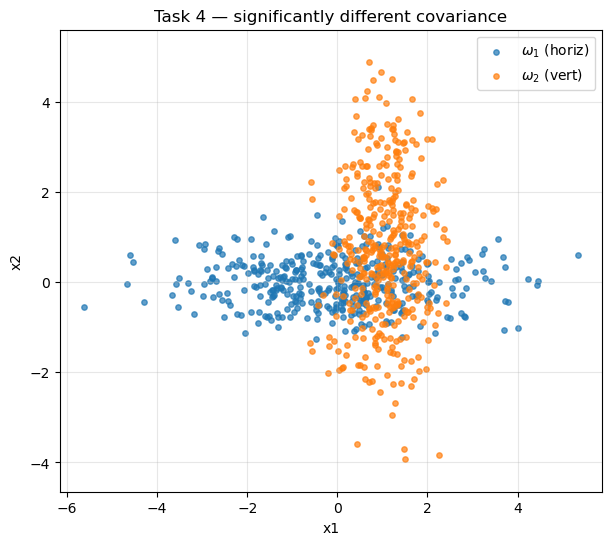

In [20]:
np.random.seed(42)

mu_a = np.array([0.0, 0.0])
mu_b = np.array([1.0, 0.5])

Sigma_a = np.array([[3.0, 0.0],
                    [0.0, 0.3]]) # horizontalno izduzena
Sigma_b = np.array([[0.3, 0.0],
                    [0.0, 3.0]]) # vertikalno izduzena

n4 = 400
Xa = np.random.multivariate_normal(mu_a, Sigma_a, size=n4)
Xb = np.random.multivariate_normal(mu_b, Sigma_b, size=n4)

X4 = np.vstack([Xa, Xb])
y4 = np.array([1] * n4 + [2] * n4)

plt.figure(figsize=(7, 6))
plt.scatter(Xa[:, 0], Xa[:, 1], s=15, alpha=0.7, label=r"$\omega_1$ (horiz)")
plt.scatter(Xb[:, 0], Xb[:, 1], s=15, alpha=0.7, label=r"$\omega_2$ (vert)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("Task 4 — significantly different covariance")
plt.legend(); plt.grid(True, alpha=0.3); plt.axis('equal')
plt.show()

In [21]:
X4_train, X4_test, y4_train, y4_test = stratified_split(X4, y4, test_size=0.3, seed=2)

qda_means4, qda_covs4, qda_priors4 = fit_qda(X4_train, y4_train)
lda_means4, lda_pooled4, lda_priors4 = fit_lda(X4_train, y4_train)

y4_pred_lda = predict_lda(X4_test, lda_means4, lda_pooled4, lda_priors4)
y4_pred_qda = predict_qda(X4_test, qda_means4, qda_covs4, qda_priors4)

print("=== Test performace ===\n")
report_metrics(y4_test, y4_pred_lda, "LDA")
print()
report_metrics(y4_test, y4_pred_qda, "QDA")

=== Test performace ===

--- LDA ---
Confusion matrix (rows = T, cols = P):
          pred=1   pred=2
true=1       70       50
true=2       22       98
Accuracy:              0.7000
Empirical error rate:  0.3000

--- QDA ---
Confusion matrix (rows = T, cols = P):
          pred=1   pred=2
true=1       91       29
true=2       14      106
Accuracy:              0.8208
Empirical error rate:  0.1792


(array([[ 91,  29],
        [ 14, 106]]),
 np.float64(0.8208333333333333),
 np.float64(0.1791666666666667))

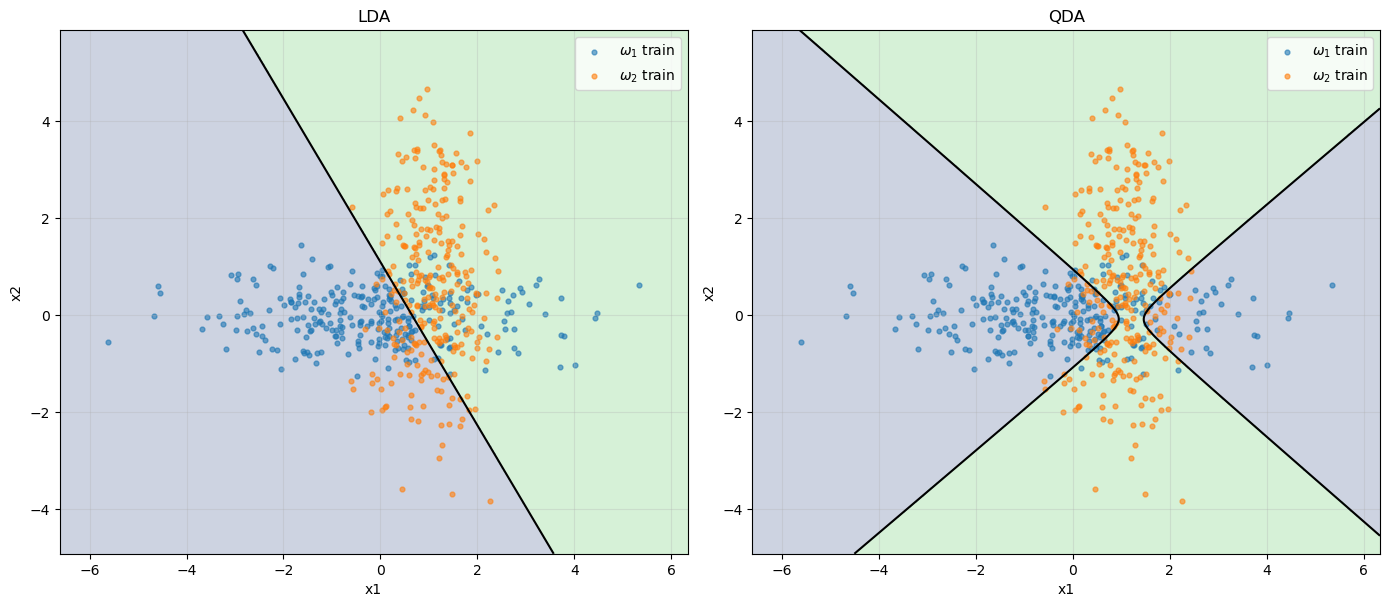

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

specs4 = [
    ("LDA",
     lambda Xg: predict_lda(Xg, lda_means4, lda_pooled4, lda_priors4),
     lambda Xg: (log_gaussian_pdf(Xg, lda_means4[1], lda_pooled4) + np.log(lda_priors4[1])
                 - log_gaussian_pdf(Xg, lda_means4[2], lda_pooled4) - np.log(lda_priors4[2]))),
    ("QDA",
     lambda Xg: predict_qda(Xg, qda_means4, qda_covs4, qda_priors4),
     lambda Xg: (log_gaussian_pdf(Xg, qda_means4[1], qda_covs4[1]) + np.log(qda_priors4[1])
                 - log_gaussian_pdf(Xg, qda_means4[2], qda_covs4[2]) - np.log(qda_priors4[2]))),
]

Xa_tr = X4_train[y4_train == 1]; Xb_tr = X4_train[y4_train == 2]

for ax, (title, pred_fn, score_fn) in zip(axes, specs4):
    xx, yy, grid = make_grid(X4)
    Z = pred_fn(grid).reshape(xx.shape)
    S = score_fn(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, levels=[0.5, 1.5, 2.5])
    ax.contour(xx, yy, S, levels=[0.0], colors='black', linewidths=1.5)
    ax.scatter(Xa_tr[:, 0], Xa_tr[:, 1], s=12, alpha=0.6, label=r"$\omega_1$ train")
    ax.scatter(Xb_tr[:, 0], Xb_tr[:, 1], s=12, alpha=0.6, label=r"$\omega_2$ train")
    ax.set_title(title); ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

### Discussion

- **Why is LDA not an appropriate assumption in this case?**  
  LDA assumes $\Sigma_1 = \Sigma_2$, i.e., equal covariance matrices. In our construction, one class is strongly horizontally elongated ($\Sigma_a = \mathrm{diag}(3,\,0.3)$), while the other is vertically elongated ($\Sigma_b = \mathrm{diag}(0.3,\,3)$). The pooled covariance effectively “blurs” both orientations and produces an almost isotropic estimate of $\Sigma$, leading to a linear decision boundary that cannot capture the true quadratic structure (here resembling a cross-shaped or hyperbolic boundary).

- **Why is QDA a better fit?**  
  QDA models $\Sigma_k$ separately for each class, allowing it to capture different anisotropies. This results in a **quadratic** decision boundary. The Bayes-optimal boundary for two Gaussians with different covariance matrices is inherently quadratic (including lines, ellipses, parabolas, or hyperbolas as special cases).

- **Is QDA always better in practice?**  
  No. QDA has more parameters (a separate $\Sigma_k$ for each class — $O(d^2)$ per class), which makes it prone to **overfitting** when the number of samples per class is small relative to the dimensionality. In such cases, LDA, with a shared covariance matrix, provides more stable estimates and can achieve lower test error. Additionally, if the true covariances are similar, QDA’s extra flexibility may increase variance without reducing bias. The best choice depends on (1) the ratio $n / d^2$ per class and (2) how different the true covariance matrices actually are.

## how do they do in practice? - sklearn comparison

In [ ]:

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

lda_sk = LinearDiscriminantAnalysis(store_covariance=True).fit(X_train, y_train)
qda_sk = QuadraticDiscriminantAnalysis(store_covariance=True).fit(X_train, y_train)

print("--- Task 3 (sklearn) ---")
print("LDA test accuracy:", accuracy_score(y_test, lda_sk.predict(X_test)))
print("QDA test accuracy:", accuracy_score(y_test, qda_sk.predict(X_test)))
print("LDA confusion:\n", confusion_matrix(y_test, lda_sk.predict(X_test)))
print("QDA confusion:\n", confusion_matrix(y_test, qda_sk.predict(X_test)))

lda_sk4 = LinearDiscriminantAnalysis(store_covariance=True).fit(X4_train, y4_train)
qda_sk4 = QuadraticDiscriminantAnalysis(store_covariance=True).fit(X4_train, y4_train)

print("\n--- Task 4 (sklearn) ---")
print("LDA test accuracy:", accuracy_score(y4_test, lda_sk4.predict(X4_test)))
print("QDA test accuracy:", accuracy_score(y4_test, qda_sk4.predict(X4_test)))

--- Task 3 (sklearn) ---
LDA test accuracy: 0.9083333333333333
QDA test accuracy: 0.9
LDA confusion:
 [[108  12]
 [ 10 110]]
QDA confusion:
 [[111   9]
 [ 15 105]]

--- Task 4 (sklearn) ---
LDA test accuracy: 0.7
QDA test accuracy: 0.8208333333333333
